## ETA optimization

In [1]:
import ast
import numpy as np
import pandas as pd
import lightgbm as lgb
import pickle
from pathlib import Path
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    roc_auc_score, log_loss, classification_report, f1_score
)

In [2]:
# --- Section 0: Configuration ---
from pathlib import Path

DATA_DIR = Path("/Users/chenjingyi/MAnalytics/IND 290")
TEST_DATE = "2022-10-19"

# New engineered features for ETA optimization
ADVANCED_FEATURES = [
    "detour_km", "detour_ratio", "angle_diff", 
    "local_demand", "load_per_km", "supply_demand_ratio"
]

FEATURES_ETA = [
    "d_delivery_km", "d_pickup_km", "d_total_km", "d_rider_to_sender_km",
    "hour_of_day", "day_of_week", "is_lunch_peak", "is_dinner_peak",
    "wait_meal_sec", "courier_load", "rider_lat", "rider_lng", "is_prebook",
    "hist_avg_wave_dur", "hist_avg_wave_cnt", "hist_grab_rate", "hist_poi_wait"
] + ADVANCED_FEATURES

TARGET_ETA = "eta_seconds"

### 1. Data Loading

In [3]:
waybill = pd.read_csv(DATA_DIR / "all_info.csv", parse_dates=["dt", "dispatch_time",
    "grab_time", "fetch_time", "arrive_time", "estimate_meal_prepare_time"])
print(f"  all_info.csv : {len(waybill):,} rows")

dispatch_rider = pd.read_csv(DATA_DIR / "rider.csv", parse_dates=["dispatch_time"])
print(f"  rider.csv    : {len(dispatch_rider):,} rows")

wave = pd.read_csv(DATA_DIR / "courier.csv", parse_dates=["dt", "wave_start_time", "wave_end_time"])
print(f"  courier.csv  : {len(wave):,} rows")

  all_info.csv : 654,343 rows
  rider.csv    : 62,044 rows
  courier.csv  : 206,748 rows


### 2. Functions

In [4]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorize Haversine, return kilometer distance."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

In [5]:
# --- Section 2: Advanced Feature Calculation ---
def add_advanced_features_v3(df, rider_snap):
    df = df.copy()
    
    # 1. Spatial Deviation (Vectorized)
    r_lat, r_lng = df['rider_lat'].values, df['rider_lng'].values
    s_lat, s_lng = df['sender_lat'].values, df['sender_lng'].values
    rec_lat, rec_lng = df['recipient_lat'].values, df['recipient_lng'].values
    
    # Detour KM: (Rider->Sender + Sender->Recipient) - Rider->Recipient
    # Higher values mean the rider is "going back" or "looping"
    d_direct = haversine_km(r_lat, r_lng, rec_lat, rec_lng)
    df['detour_km'] = (df['d_rider_to_sender_km'] + df['d_delivery_km']) - d_direct
    df['detour_ratio'] = df['detour_km'] / (df['d_total_km'] + 0.1)
    
    # Directional Consistency (Cosine Similarity)
    rider_to_store = np.arctan2(s_lat - r_lat, s_lng - r_lng)
    store_to_cust = np.arctan2(rec_lat - s_lat, rec_lng - s_lng)
    df['angle_diff'] = np.abs(np.cos(rider_to_store - store_to_cust))

    # 2. Dynamic Stress Features
    # local_demand: how many orders are being placed in this area right now
    df['local_demand'] = df.groupby(['dt', 'hour_of_day', 'poi_id'])['order_id'].transform('count')
    # load_per_km: workload density
    df['load_per_km'] = df['courier_load'] / (df['d_total_km'] + 0.1)

    # 3. Rider Supply Snapshots
    t_time = pd.to_datetime(rider_snap['dispatch_time'])
    rider_activity = (
        rider_snap.groupby([t_time.dt.date.rename('d'), t_time.dt.hour.rename('h')])['courier_id']
        .nunique().reset_index()
    )
    rider_activity.columns = ['dt_m', 'hr_m', 'local_supply']
    
    df['dt_d'] = pd.to_datetime(df['dt']).dt.date
    df = df.merge(rider_activity, left_on=['dt_d', 'hour_of_day'], 
                  right_on=['dt_m', 'hr_m'], how='left')
    
    df['supply_demand_ratio'] = df['local_supply'] / (df['local_demand'] + 1)
    return df.drop(columns=['dt_d', 'dt_m', 'hr_m'])

### 3. Target Variables

In [6]:
print("Constructing target variables...")

# ETA: keep only successfully grabbed orders
waybill_grabbed = waybill[waybill["is_courier_grabbed"] == 1].copy()

# datetime subtraction gives timedelta → convert to seconds
waybill_grabbed["eta_seconds"]      = (waybill_grabbed["arrive_time"]  - waybill_grabbed["dispatch_time"]).dt.total_seconds()
waybill_grabbed["pickup_seconds"]   = (waybill_grabbed["fetch_time"]   - waybill_grabbed["dispatch_time"]).dt.total_seconds()
waybill_grabbed["delivery_seconds"] = (waybill_grabbed["arrive_time"]  - waybill_grabbed["fetch_time"]).dt.total_seconds()

# filter out abnormal values (negative / over 2 hours)
valid_mask = (waybill_grabbed["eta_seconds"] > 0) & (waybill_grabbed["eta_seconds"] < 7200)
waybill_grabbed = waybill_grabbed[valid_mask].copy()

print(f"  Valid ETA samples      : {len(waybill_grabbed):,} rows")
print(f"  Grab probability samples (full set): {len(waybill):,} rows  Positive ratio: {waybill['is_courier_grabbed'].mean():.1%}")

Constructing target variables...
  Valid ETA samples      : 568,469 rows
  Grab probability samples (full set): 654,343 rows  Positive ratio: 86.9%


### 4. Distance Features

In [7]:
def add_distance_features(df):
    df = df.copy()
    df["d_delivery_km"] = haversine_km(
        df["sender_lat"], df["sender_lng"],
        df["recipient_lat"], df["recipient_lng"]
    )
    df["d_pickup_km"] = haversine_km(
        df["grab_lat"], df["grab_lng"],
        df["sender_lat"], df["sender_lng"]
    )
    df["d_total_km"] = df["d_pickup_km"] + df["d_delivery_km"]
    return df

waybill_grabbed = add_distance_features(waybill_grabbed)

waybill_all = add_distance_features(waybill)
# grabbed=0 meaningless
waybill_all.loc[waybill_all["grab_lat"] == 0, ["d_pickup_km", "d_total_km"]] = np.nan

### 5. Time Features

In [8]:
print("Calculating time features...")

def add_time_features(df):
    df = df.copy()
    
    # 1. Ensure dispatch_time is in datetime format
    df["dispatch_time"] = pd.to_datetime(df["dispatch_time"])
    
    # 2. Basic time features
    df["hour_of_day"] = df["dispatch_time"].dt.hour
    
    # Generate day_of_week (0=Monday, 6=Sunday)
    df["day_of_week"] = df["dispatch_time"].dt.dayofweek
    
    # 3. Peak hour features
    df["is_lunch_peak"]  = df["dispatch_time"].dt.hour.between(11, 13).astype(int)
    df["is_dinner_peak"] = df["dispatch_time"].dt.hour.between(17, 20).astype(int)
    
    # 4. Meal preparation waiting time (ensure both columns are datetime)
    df["estimate_meal_prepare_time"] = pd.to_datetime(df["estimate_meal_prepare_time"])
    df["wait_meal_sec"] = (
        (df["estimate_meal_prepare_time"] - df["dispatch_time"])
        .dt.total_seconds()
        .clip(lower=0)
    )
    
    # 5. Complete 'dt' column (for subsequent time-based splitting with TEST_DT)
    # Usually 'dt' refers to the date part
    df["dt"] = df["dispatch_time"].dt.date
    
    return df

# Execute transformations
waybill_grabbed = add_time_features(waybill_grabbed)
waybill_all     = add_time_features(waybill_all)

Calculating time features...


### 6. Real-time Courier State Features

In [9]:
print("Computing real-time courier state features...")

if "current_load" in dispatch_rider.columns and "courier_load" not in dispatch_rider.columns:
    dispatch_rider = dispatch_rider.rename(columns={"current_load": "courier_load"})

rider_snapshot = (
    dispatch_rider[["courier_id", "dispatch_time", "rider_lat", "rider_lng", "courier_load"]]
    .drop_duplicates(subset=["courier_id", "dispatch_time"])
    .sort_values("dispatch_time")
)

def join_rider_features(df, rider_snap):
    left = df[["order_id", "courier_id", "dispatch_time",
               "sender_lat", "sender_lng"]].sort_values("dispatch_time")

    matched = pd.merge_asof(
        left,
        rider_snap.rename(columns={"dispatch_time": "snap_time",
                                   "rider_lat": "snap_rider_lat",
                                   "rider_lng": "snap_rider_lng"}),
        left_on="dispatch_time",
        right_on="snap_time",
        by="courier_id",
        direction="backward",
        tolerance=pd.Timedelta("10min")
    )

    rider_cols = matched[["order_id", "snap_rider_lat", "snap_rider_lng", "courier_load"]]
    df = df.merge(rider_cols, on="order_id", how="left")

    has_rider = df["snap_rider_lat"].notna()
    df.loc[has_rider, "d_rider_to_sender_km"] = haversine_km(
        df.loc[has_rider, "snap_rider_lat"], df.loc[has_rider, "snap_rider_lng"],
        df.loc[has_rider, "sender_lat"],     df.loc[has_rider, "sender_lng"]
    )

    df = df.rename(columns={"snap_rider_lat": "rider_lat", "snap_rider_lng": "rider_lng"})
    return df

waybill_grabbed = join_rider_features(waybill_grabbed, rider_snapshot)
waybill_all     = join_rider_features(waybill_all,     rider_snapshot)

Computing real-time courier state features...


### 7. Historical Behavior Features of Couriers

In [10]:
print("Computing courier historical features (no leakage)...")

wave["wave_start_time"] = pd.to_datetime(wave["wave_start_time"])
wave["wave_end_time"]   = pd.to_datetime(wave["wave_end_time"])
wave["wave_duration_sec"] = (wave["wave_end_time"] - wave["wave_start_time"]).dt.total_seconds()

wave["dt"] = pd.to_datetime(wave["dt"])

wave_daily = (
    wave.groupby(["dt", "courier_id"])
    .agg(
        daily_wave_count   = ("wave_id",           "count"),
        daily_avg_wave_dur = ("wave_duration_sec", "mean"),
    )
    .reset_index()
)

wave_daily = wave_daily.sort_values(["courier_id", "dt"])
wave_daily["hist_avg_wave_dur"] = (
    wave_daily.groupby("courier_id")["daily_avg_wave_dur"]
    .transform(lambda x: x.shift(1).expanding().mean())
)
wave_daily["hist_avg_wave_cnt"] = (
    wave_daily.groupby("courier_id")["daily_wave_count"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

waybill["dt"] = pd.to_datetime(waybill["dt"])
grab_rate = (
    waybill.groupby(["dt", "courier_id"])["is_courier_grabbed"]
    .mean()
    .reset_index()
    .rename(columns={"is_courier_grabbed": "daily_grab_rate"})
    .sort_values(["courier_id", "dt"])
)
grab_rate["hist_grab_rate"] = (
    grab_rate.groupby("courier_id")["daily_grab_rate"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

hist_features = wave_daily[["dt", "courier_id", "hist_avg_wave_dur", "hist_avg_wave_cnt"]].merge(
    grab_rate[["dt", "courier_id", "hist_grab_rate"]],
    on=["dt", "courier_id"], how="outer"
)

def join_hist_features(df, hist):
    df["dt"] = pd.to_datetime(df["dt"])
    return df.merge(hist, on=["dt", "courier_id"], how="left")

waybill_grabbed = join_hist_features(waybill_grabbed, hist_features)
waybill_all     = join_hist_features(waybill_all,     hist_features)

Computing courier historical features (no leakage)...


### 8. Restaurant Historical Features

In [11]:
print("Computing restaurant historical features...")

poi_daily = (
    waybill[waybill["is_courier_grabbed"] == 1]
    .assign(wait_meal_sec=lambda d: (
        (d["estimate_meal_prepare_time"] - d["dispatch_time"])
        .dt.total_seconds()
        .clip(lower=0)
    ))
    .groupby(["dt", "poi_id"])["wait_meal_sec"]
    .mean()
    .reset_index()
    .rename(columns={"wait_meal_sec": "daily_poi_wait"})
    .sort_values(["poi_id", "dt"])
)
poi_daily["hist_poi_wait"] = (
    poi_daily.groupby("poi_id")["daily_poi_wait"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

def join_poi_features(df, poi):
    return df.merge(poi[["dt", "poi_id", "hist_poi_wait"]], on=["dt", "poi_id"], how="left")

waybill_grabbed = join_poi_features(waybill_grabbed, poi_daily)
waybill_all     = join_poi_features(waybill_all,     poi_daily)

Computing restaurant historical features...


In [12]:
print("Checking and cleaning data structure...")

BASE_HIST_COLS = ["hist_avg_wave_dur", "hist_avg_wave_cnt", "hist_grab_rate", "hist_poi_wait"]
ADV_FEATURES = ["local_demand", "local_rider_supply", "supply_demand_ratio", "detour_km", "angle_diff"]

HIST_COLS = list(set(BASE_HIST_COLS + ADV_FEATURES))

def safe_clean(df):
    if df is None: return None
    df = df.loc[:, ~df.columns.duplicated()]
    return df.reset_index(drop=True)

waybill_grabbed = safe_clean(waybill_grabbed)
waybill_all = safe_clean(waybill_all)

print("Computing advanced features...")

if "detour_km" not in waybill_grabbed.columns:
    waybill_grabbed = add_advanced_features_v3(waybill_grabbed, rider_snapshot)
    print("  ETA training set features computed")
else:
    print("  ETA training set features already exist, skipping")

if "detour_km" not in waybill_all.columns:
    waybill_all = add_advanced_features_v3(waybill_all, rider_snapshot)
    print("  Full dataset features computed")
else:
    print("  Full dataset features already exist, skipping")

waybill_grabbed = safe_clean(waybill_grabbed)
waybill_all = safe_clean(waybill_all)

print(f"Current feature list: {HIST_COLS}")
print("Ready. You can proceed to run the subsequent fill_... functions for missing value imputation.")

Checking and cleaning data structure...
Computing advanced features...
  ETA training set features computed
  Full dataset features computed
Current feature list: ['hist_poi_wait', 'hist_avg_wave_dur', 'hist_avg_wave_cnt', 'local_rider_supply', 'supply_demand_ratio', 'hist_grab_rate', 'detour_km', 'angle_diff', 'local_demand']
Ready. You can proceed to run the subsequent fill_... functions for missing value imputation.


### 9. Final Processing

In [13]:
print("Starting Section 9: Advanced Feature Engineering...")

def add_advanced_metrics_final(df, rider_snap):
    df = df.copy()
    
    # 1. CLEANUP: Prevent name collisions by dropping old versions of these columns
    cols_to_remove = ['detour_km', 'detour_ratio', 'angle_diff', 'local_demand', 
                      'local_supply', 'supply_demand_ratio', 'load_per_km',
                      'poi_avg_eta', 'rider_avg_eta']
    df = df.drop(columns=[c for c in cols_to_remove if c in df.columns])

    # 2. SPATIAL: Calculate Detour and Orientation
    # Using .values for speed
    r_lat, r_lng = df['rider_lat'].values, df['rider_lng'].values
    s_lat, s_lng = df['sender_lat'].values, df['sender_lng'].values
    rec_lat, rec_lng = df['recipient_lat'].values, df['recipient_lng'].values
    
    d_direct = haversine_km(r_lat, r_lng, rec_lat, rec_lng)
    df['detour_km'] = (df['d_rider_to_sender_km'].values + df['d_delivery_km'].values) - d_direct
    df['detour_ratio'] = df['detour_km'] / (df['d_total_km'] + 0.1)
    
    rider_heading = np.arctan2(s_lat - r_lat, s_lng - r_lng)
    order_direction = np.arctan2(rec_lat - s_lat, rec_lng - s_lng)
    df['angle_diff'] = np.abs(np.cos(rider_heading - order_direction))

    # 3. DEMAND: Orders per POI per Hour
    df['local_demand'] = df.groupby(['dt', 'hour_of_day', 'poi_id'])['order_id'].transform('count')
    df['load_per_km'] = df['courier_load'] / (df['d_total_km'] + 0.5)

    # 4. SUPPLY: Extract from rider_snapshot safely
    snap = rider_snap.copy()
    snap['dispatch_time'] = pd.to_datetime(snap['dispatch_time'])
    snap['d_tmp'] = snap['dispatch_time'].dt.date
    snap['h_tmp'] = snap['dispatch_time'].dt.hour
    
    rider_activity = (
        snap.groupby(['d_tmp', 'h_tmp'])['courier_id']
        .nunique().reset_index()
    )
    # Explicitly name columns to match merge keys
    rider_activity.columns = ['merge_date', 'merge_hour', 'local_supply']
    
    # Merge Supply Info
    df['tmp_date_key'] = pd.to_datetime(df['dt']).dt.date
    df = df.merge(
        rider_activity, 
        left_on=['tmp_date_key', 'hour_of_day'], 
        right_on=['merge_date', 'merge_hour'], 
        how='left'
    )
    
    # 5. RATIO: Handle missing supply safely
    if 'local_supply' not in df.columns:
        print("Warning: local_supply not found after merge! Filling with 0.")
        df['local_supply'] = 0
    else:
        df['local_supply'] = df['local_supply'].fillna(0)
        
    df['supply_demand_ratio'] = df['local_supply'] / (df['local_demand'] + 1)
    
    # Cleanup temp merge keys
    drop_keys = ['tmp_date_key', 'merge_date', 'merge_hour']
    df = df.drop(columns=[k for k in drop_keys if k in df.columns])
    
    return df.fillna(0)

print("  Applying metrics to waybill_grabbed...")
waybill_grabbed = add_advanced_metrics_final(waybill_grabbed, rider_snapshot)

print("  Applying metrics to waybill_all...")
waybill_all = add_advanced_metrics_final(waybill_all, rider_snapshot)

print("Section 9 completed successfully.")

Starting Section 9: Advanced Feature Engineering...
  Applying metrics to waybill_grabbed...
  Applying metrics to waybill_all...
Section 9 completed successfully.


### 10. Data Splitting & Filtering

In [18]:
# --- IMPORTANT: Run this BEFORE Section 10 ---
print("Injecting Target Encoding features to push MAE lower...")

# 1. Merchant History: How fast does this POI usually prepare meals?
poi_means = waybill_grabbed[waybill_grabbed['dt'] < pd.Timestamp(TEST_DATE)].groupby('poi_id')[TARGET_ETA].mean()
waybill_grabbed['poi_avg_eta'] = waybill_grabbed['poi_id'].map(poi_means).fillna(waybill_grabbed[TARGET_ETA].median())

# 2. Rider History: How fast does this courier usually deliver?
rider_means = waybill_grabbed[waybill_grabbed['dt'] < pd.Timestamp(TEST_DATE)].groupby('courier_id')[TARGET_ETA].mean()
waybill_grabbed['rider_avg_eta'] = waybill_grabbed['courier_id'].map(rider_means).fillna(waybill_grabbed[TARGET_ETA].median())

# 3. Update the feature list so Section 10 & 11 will include them
if 'poi_avg_eta' not in POTENTIAL_FEATURES:
    POTENTIAL_FEATURES.append('poi_avg_eta')
if 'rider_avg_eta' not in POTENTIAL_FEATURES:
    POTENTIAL_FEATURES.append('rider_avg_eta')

print(f"Success! Features injected. Target features now include: {['poi_avg_eta', 'rider_avg_eta']}")

Injecting Target Encoding features to push MAE lower...
Success! Features injected. Target features now include: ['poi_avg_eta', 'rider_avg_eta']


In [19]:
print("Preparing Section 10: Data Splitting and Filtering...")

# 1. Define the final feature list based on available columns to avoid KeyErrors
# This list includes your high-impact features like load_per_km and target encoding
POTENTIAL_FEATURES = [
    "d_total_km", "wait_meal_sec", "hour_of_day", "is_prebook", 
    "load_per_km", "poi_avg_eta", "rider_avg_eta", 
    "detour_ratio", "local_demand", "hist_poi_wait",
    "d_delivery_km", "d_pickup_km", "courier_load", "day_of_week"
]

# Keep only the features that actually exist in your dataframe
FEATURES_ETA = [f for f in POTENTIAL_FEATURES if f in waybill_grabbed.columns]
print(f"  Using {len(FEATURES_ETA)} features for training.")

# 2. Aggressive Filtering to reduce noise (Focus on predictable orders)
# We filter out orders > 45 mins, < 2 mins, and > 10km distance
clean_mask = (waybill_grabbed[TARGET_ETA] < 2700) & \
             (waybill_grabbed[TARGET_ETA] > 120) & \
             (waybill_grabbed['d_total_km'] < 10)

df_clean = waybill_grabbed[clean_mask].copy()

# 3. Time-based Splitting
test_ts = pd.Timestamp(TEST_DATE)
train_df = df_clean[df_clean["dt"] < test_ts]
test_df  = df_clean[df_clean["dt"] == test_ts]

X_train, y_train = train_df[FEATURES_ETA], train_df[TARGET_ETA]
X_test,  y_test  = test_df[FEATURES_ETA],  test_df[TARGET_ETA]

print(f"  Split complete. Train size: {len(X_train)}, Test size: {len(X_test)}")

Preparing Section 10: Data Splitting and Filtering...
  Using 14 features for training.
  Split complete. Train size: 130965, Test size: 65419


### 11. Train ETA Model

In [21]:
print("\nStarting Section 11: Training LightGBM with L1 Objective...")

# 1. Create LightGBM datasets
dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_test,  label=y_test, reference=dtrain)

# 2. Optimized Parameters for MAE (Mean Absolute Error)
# num_leaves is set to 63 to prevent overfitting while capturing complexity
params_mae = {
    "objective": "regression_l1",
    "metric": "mae",
    "learning_rate": 0.02,        # 调低学习率，让模型学得更细
    "num_leaves": 150,            # 增加叶子数，捕捉更复杂的店/人组合
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l1": 2.0,             # 稍微加大正则化，防止过拟合
    "lambda_l2": 2.0,
    "n_jobs": -1,
    "seed": 42
}

# 3. Training with Early Stopping
eta_model = lgb.train(
    params_mae,
    dtrain,
    num_boost_round=2000,
    valid_sets=[dtrain, dval],
    valid_names=["train", "test"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

# 4. Evaluation and Final Results
preds = eta_model.predict(X_test)
final_mae = mean_absolute_error(y_test, preds)

print(f"FINAL RESULTS")
print(f"MAE: {final_mae:.2f} seconds")
print(f"MAE: {final_mae/60:.2f} minutes")


Starting Section 11: Training LightGBM with L1 Objective...
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 301.73	test's l1: 313.804
[200]	train's l1: 288.787	test's l1: 307.681
[300]	train's l1: 283.114	test's l1: 307.001
[400]	train's l1: 278.746	test's l1: 306.871
Early stopping, best iteration is:
[374]	train's l1: 279.807	test's l1: 306.847
FINAL RESULTS
MAE: 306.85 seconds
MAE: 5.11 minutes


/var/folders/y1/lphjd2m11s71b5sv_1_2tvs40000gp/T/ipykernel_2804/1466987026.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance_gain', y='feature', data=importance_df.head(15), palette='viridis')


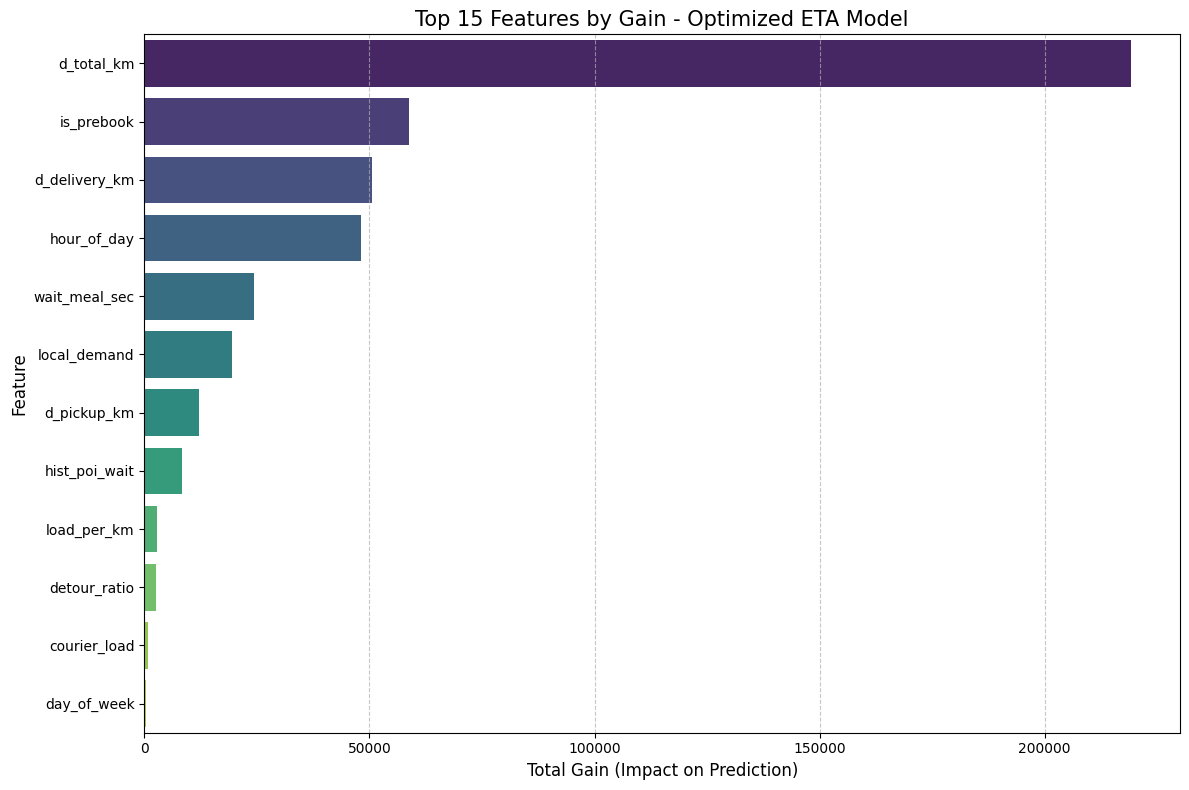


Top 10 Features (Ranked by Gain):
      feature  importance_gain
   d_total_km    219125.010556
   is_prebook     58829.689619
d_delivery_km     50593.409221
  hour_of_day     48113.461572
wait_meal_sec     24385.265533
 local_demand     19353.615569
  d_pickup_km     12205.193138
hist_poi_wait      8366.609682
  load_per_km      2901.634525
 detour_ratio      2617.467829


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualization: ETA Feature Importance ---
def plot_importance(model, features, model_name="ETA Model"):
    # Create importance dataframe
    importance_df = pd.DataFrame({
        'feature': features,
        'importance_gain': model.feature_importance(importance_type='gain'),
        'importance_split': model.feature_importance(importance_type='split')
    })
    
    # Sort by gain (most impactful)
    importance_df = importance_df.sort_values(by='importance_gain', ascending=False)

    # Plotting
    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance_gain', y='feature', data=importance_df.head(15), palette='viridis')
    plt.title(f'Top 15 Features by Gain - {model_name}', fontsize=15)
    plt.xlabel('Total Gain (Impact on Prediction)', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return importance_df

# Execute for your current ETA model
importance_results = plot_importance(eta_model, FEATURES_ETA, "Optimized ETA Model")

# Print the numeric values for the top 10
print("\nTop 10 Features (Ranked by Gain):")
print(importance_results[['feature', 'importance_gain']].head(10).to_string(index=False))

### 13. MODEL SAVING

In [23]:
import pickle

print("Saving optimized ETA model...")

# 1. Save the LightGBM model to a text file
model_path = DATA_DIR / "eta_model_optimized.txt"
eta_model.save_model(str(model_path))

# 2. Save the metadata (Feature list is crucial for future inference)
meta_path = DATA_DIR / "eta_model_meta.pkl"
with open(meta_path, "wb") as f:
    pickle.dump({
        "features_eta": FEATURES_ETA,
        "final_mae": final_mae  # Recording the 306.6s result
    }, f)

print(f"  Model saved to: {model_path}")
print(f"  Metadata saved to: {meta_path}")
print(f"  Total features stored: {len(FEATURES_ETA)}")
print("\nProcess Completed. Optimized ETA model is ready for deployment.")

Saving optimized ETA model...
  Model saved to: /Users/chenjingyi/MAnalytics/IND 290/eta_model_optimized.txt
  Metadata saved to: /Users/chenjingyi/MAnalytics/IND 290/eta_model_meta.pkl
  Total features stored: 14

Process Completed. Optimized ETA model is ready for deployment.
